In [1]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

from datos_processing import load_and_prepare_all
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = load_and_prepare_all()

x_train = data["x_train_mlp"]
y_train = data["y_train"]
x_test = data["x_test_mlp"]
y_test = data["y_test"]
class_names = data["class_names"]

In [3]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\valex\PycharmProjects\Fashion-MNIST\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.8055 - loss: 0.5421 - val_accuracy: 0.8547 - val_loss: 0.3961
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8500 - loss: 0.4120 - val_accuracy: 0.8503 - val_loss: 0.4081
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step - accuracy: 0.8605 - loss: 0.3800 - val_accuracy: 0.8672 - val_loss: 0.3505
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.8704 - loss: 0.3530 - val_accuracy: 0.8777 - val_loss: 0.3344
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.8749 - loss: 0.3389 - val_accuracy: 0.8698 - val_loss: 0.3418
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8780 - loss: 0.3293 - val_accuracy: 0.8790 - val_loss: 0.3345
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.8824 - loss: 0.3161 - val_accuracy: 0.8797 - val_loss: 0.3255
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8855 - loss

In [5]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Loss en test:", test_loss)
print("Accuracy en test:", test_acc)

Loss en test: 0.3526895046234131
Accuracy en test: 0.8712999820709229


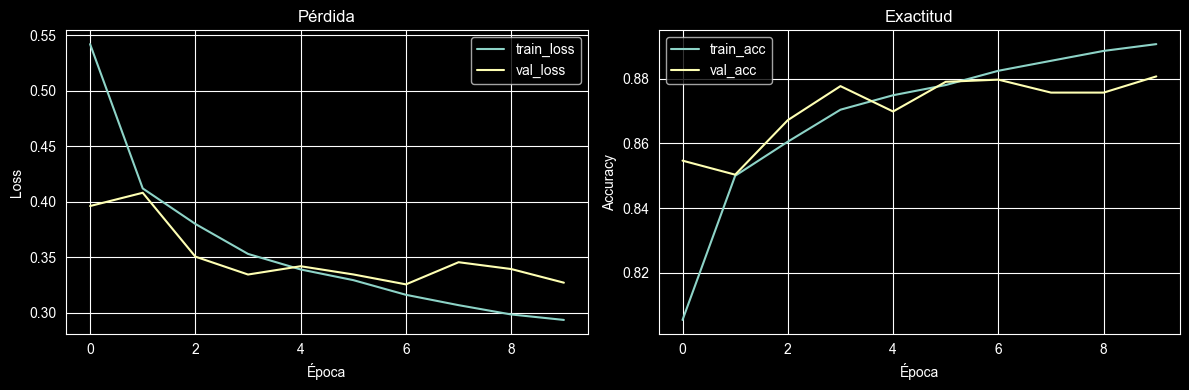

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Exactitud")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()